# Chapter 2 — Data and Sampling Distributions

## Learning Objectives

This notebook explains random sampling, sample bias, sampling distributions, standard error, the bootstrap, confidence intervals, and important probability distributions used in data science.

## Theoretical Explanation

Sampling remains important even in big data because data quality and representativeness often matter more than raw size. A biased sample can be very large and still misleading. A sampling distribution describes how a statistic, such as the mean, varies from sample to sample. This is different from the distribution of individual data points.

The central limit theorem explains why sample means often become more bell-shaped as sample size increases. Standard error measures the variability of a statistic across repeated samples. Bootstrap resampling estimates this variability empirically by sampling with replacement from the observed data, making it useful when formulas are unavailable or assumptions are weak.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Sampling Distribution and Central Limit Theorem

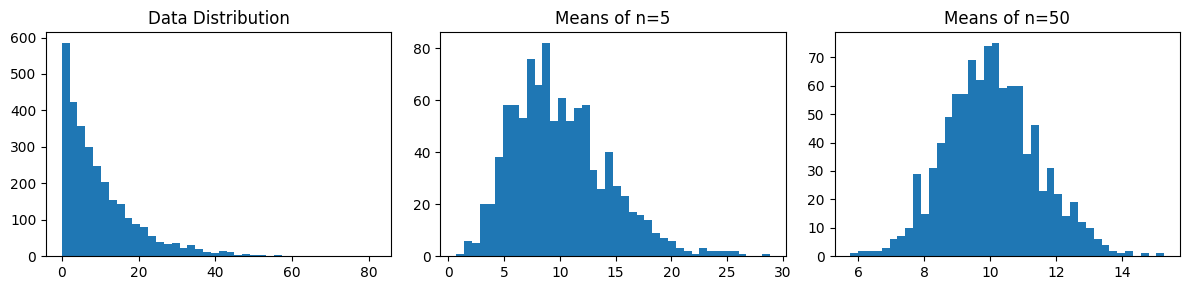

Population mean: 9.96
Standard error n=5: 4.318
Standard error n=50: 1.403


In [2]:
rng = np.random.RandomState(RANDOM_STATE)
population = rng.exponential(scale=10, size=100000)
means_5 = [rng.choice(population, size=5).mean() for _ in range(1000)]
means_50 = [rng.choice(population, size=50).mean() for _ in range(1000)]

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].hist(population[:3000], bins=40)
ax[0].set_title('Data Distribution')
ax[1].hist(means_5, bins=40)
ax[1].set_title('Means of n=5')
ax[2].hist(means_50, bins=40)
ax[2].set_title('Means of n=50')
plt.tight_layout()
plt.show()

print('Population mean:', round(population.mean(), 3))
print('Standard error n=5:', round(np.std(means_5, ddof=1), 3))
print('Standard error n=50:', round(np.std(means_50, ddof=1), 3))

### Output Interpretation

The original data is skewed, but the distribution of sample means becomes more regular as sample size increases. The standard error is smaller for n=50 than for n=5.

## 2. Bootstrap Confidence Interval

Sample mean: 9.26
Bootstrap standard error: 1.054
95% bootstrap confidence interval: [ 7.299 11.473]


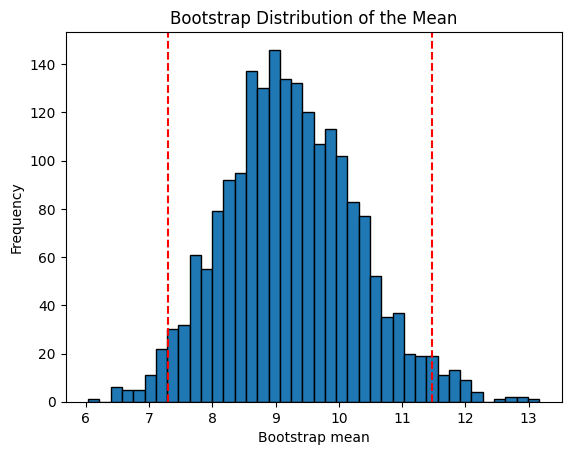

In [3]:
sample = rng.choice(population, size=80, replace=False)
boot_means = [rng.choice(sample, size=len(sample), replace=True).mean() for _ in range(2000)]
ci = np.percentile(boot_means, [2.5, 97.5])
print('Sample mean:', round(sample.mean(), 3))
print('Bootstrap standard error:', round(np.std(boot_means, ddof=1), 3))
print('95% bootstrap confidence interval:', np.round(ci, 3))

plt.hist(boot_means, bins=40, edgecolor='black')
plt.axvline(ci[0], color='red', linestyle='--')
plt.axvline(ci[1], color='red', linestyle='--')
plt.title('Bootstrap Distribution of the Mean')
plt.xlabel('Bootstrap mean')
plt.ylabel('Frequency')
plt.show()

### Output Interpretation

The bootstrap distribution estimates how the sample mean would vary if similar samples were repeatedly drawn. The confidence interval gives a practical uncertainty range around the estimate.

## 3. Probability Distributions: Binomial, Poisson, and Weibull

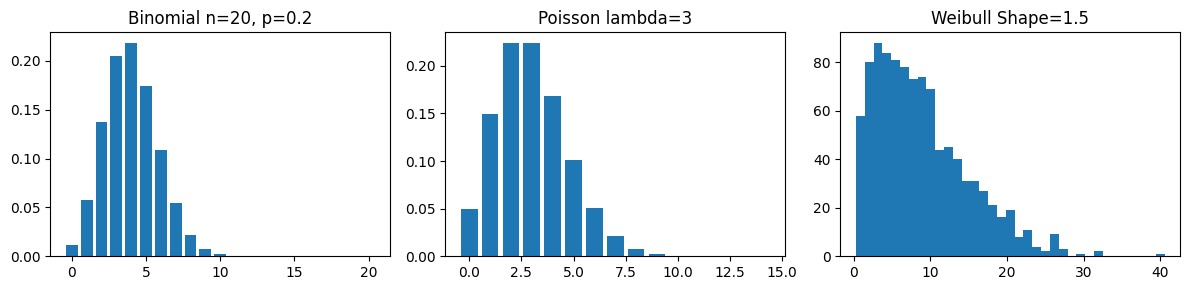

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].bar(range(21), stats.binom.pmf(range(21), n=20, p=0.2))
ax[0].set_title('Binomial n=20, p=0.2')
ax[1].bar(range(15), stats.poisson.pmf(range(15), mu=3))
ax[1].set_title('Poisson lambda=3')
weibull = stats.weibull_min.rvs(c=1.5, scale=10, size=1000, random_state=RANDOM_STATE)
ax[2].hist(weibull, bins=35)
ax[2].set_title('Weibull Shape=1.5')
plt.tight_layout()
plt.show()

### Output Interpretation

The binomial distribution models counts of successes in fixed trials. The Poisson distribution models event counts per interval. The Weibull distribution models time-to-event situations with changing failure rates.

## Extended Study Notes

The most important professional habit in practical statistics is interpretation. A statistic is not useful only because it can be computed; it is useful when it answers a real question about data quality, uncertainty, relationships, prediction, or decision-making. In data science work, the same numerical result can have different meanings depending on the sampling process, the metric used, the business cost of errors, and the assumptions behind the procedure.

This notebook intentionally uses original, simplified examples instead of copying the book examples verbatim. The purpose is academic understanding: connect the statistical concept to a runnable Python workflow, inspect the output, and explain what the output means. This also supports academic integrity because the notebook demonstrates the learned concept in original wording and with adapted code.

## Chapter Summary

This chapter was reproduced as a compact but complete study notebook. It combines conceptual explanation, Python implementation, output interpretation, and practical data science context.

## Key Takeaways

- Statistical concepts should be connected to data science decisions, not treated as isolated formulas.
- Visual summaries and resampling methods often provide practical intuition beyond formula-based statistics.
- Model evaluation must consider uncertainty, bias, sampling, and the cost of incorrect conclusions.
- The output of code should always be interpreted in context before making decisions.